# 训练（fine-tuning）与推理（Inference）

## 1. Mnist 手写数字识别
> 理解机器学习的基本流程和概念

In [ ]:
pip install torch torchvision matplotlib

Epoch [1/5], Loss: 0.7999
Epoch [2/5], Loss: 0.3100
Epoch [3/5], Loss: 0.2525
Epoch [4/5], Loss: 0.2146
Epoch [5/5], Loss: 0.1867


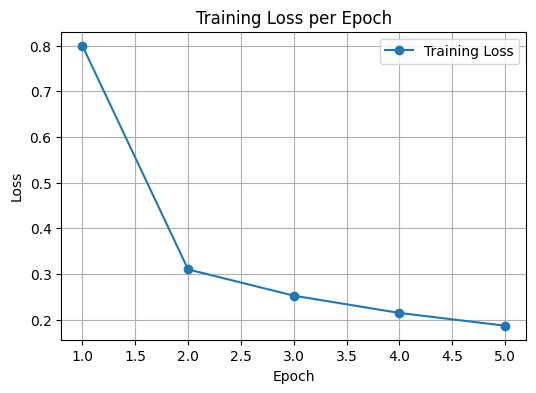

========= 模型保存成功 =========
========= 模型加载成功 =========
Test Accuracy: 94.93%


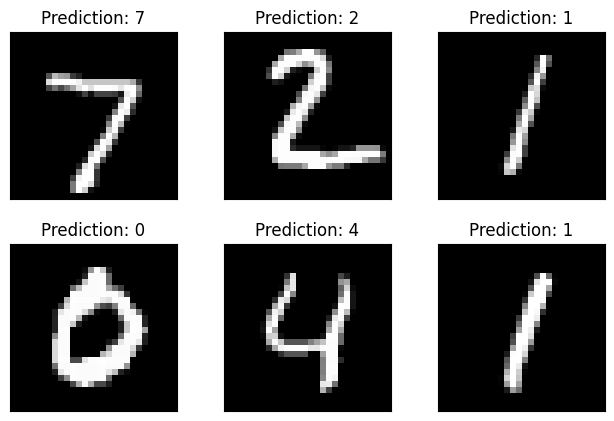

In [12]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
import matplotlib.pyplot as plt

# 1. 超参数
batch_size = 64
learning_rate = 0.01
epochs = 5

# 2. 数据加载
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))
])

train_dataset = datasets.MNIST(root='./data', train=True, download=True, transform=transform)
test_dataset = datasets.MNIST(root='./data', train=False, download=True, transform=transform)

train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = torch.utils.data.DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

# 3. 定义网络
class Net(nn.Module):
    def __init__(self):
        super(Net, self).__init__()
        self.fc1 = nn.Linear(28*28, 128)
        self.fc2 = nn.Linear(128, 64)
        self.fc3 = nn.Linear(64, 10)

    def forward(self, x):
        x = x.view(-1, 28*28)
        x = torch.relu(self.fc1(x))
        x = torch.relu(self.fc2(x))
        return self.fc3(x)

model = Net()

# 4. 损失与优化器
criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(model.parameters(), lr=learning_rate)

# 5. 训练过程并记录每轮loss
def train_and_plot():
    losses = []  # 保存每一轮的平均损失
    for epoch in range(epochs):
        total_loss = 0
        for data, target in train_loader:
            optimizer.zero_grad()
            output = model(data)
            loss = criterion(output, target)
            loss.backward()
            optimizer.step()
            total_loss += loss.item()

        avg_loss = total_loss / len(train_loader)
        losses.append(avg_loss)
        print(f"Epoch [{epoch+1}/{epochs}], Loss: {avg_loss:.4f}")

    # 绘制损失曲线
    plt.figure(figsize=(6,4))
    plt.plot(range(1, epochs+1), losses, 'o-', label="Training Loss")
    plt.title("Training Loss per Epoch")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.grid(True)
    plt.legend()
    plt.show()
    


# 6. 测试函数
def test(model):
    model.eval()
    correct = 0
    with torch.no_grad():
        for data, target in test_loader:
            output = model(data)
            pred = output.argmax(dim=1)  # 最大值所在的下标
            correct += pred.eq(target).sum().item()
    print(f'Test Accuracy: {100.0 * correct / len(test_dataset):.2f}%')

# 7. 执行训练并绘图
train_and_plot()
# 保存整个模型
torch.save(model, "mnist_full_model.pth")
print("========= 模型保存成功 =========")
# 8. 执行和测试
model = torch.load("mnist_full_model.pth", weights_only=False)
print("========= 模型加载成功 =========")
test(model)

# 9. 可视化一些预测结果
examples = enumerate(test_loader)
batch_idx, (example_data, example_targets) = next(examples)

with torch.no_grad():
    output = model(example_data)

fig = plt.figure()
for i in range(6):
    plt.subplot(2,3,i+1)
    plt.tight_layout()
    plt.imshow(example_data[i][0], cmap='gray', interpolation='none')
    plt.title(f"Prediction: {output.argmax(dim=1)[i].item()}")
    plt.xticks([])
    plt.yticks([])
plt.show()

## 2. 大模型微调
> 先安装 requirements.txt 中的所有依赖 `pip install -r requirements.txt`，再运行下面代码

中文字体设置成功
      大模型微调完整流程演示（简化版）

🚀 步骤1: 初始化微调器
使用设备: cuda

📥 步骤2: 加载预训练模型
正在加载预训练模型和分词器...


Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


模型和分词器加载完成!
模型参数数量: 66,955,010

📊 步骤3: 准备训练数据
正在准备数据...
训练集大小: 200
验证集大小: 40


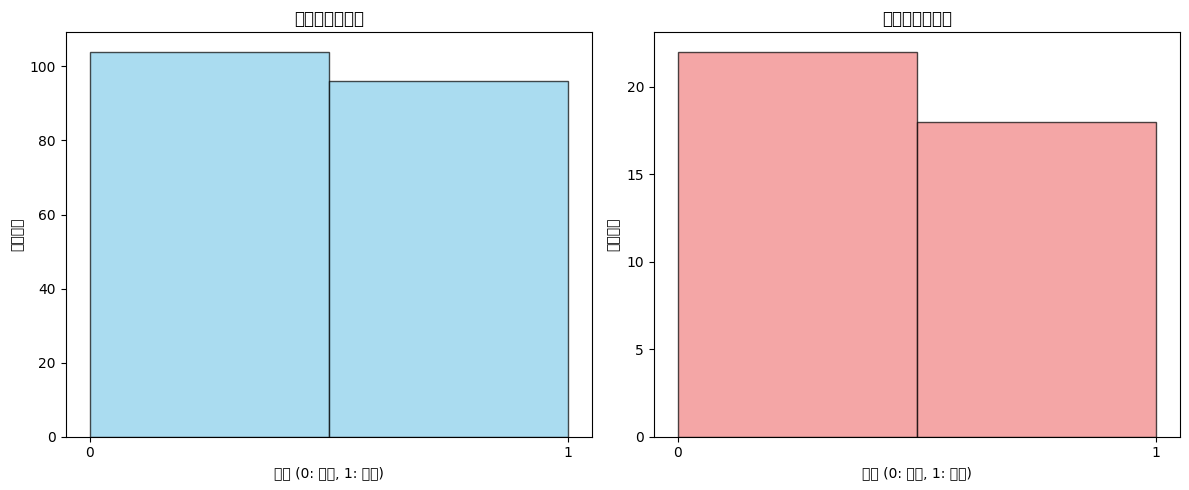


数据示例:

示例 1 (正面):
文本: There is no relation at all between Fortier and Profiler but the fact that both are police series about violent crimes. Profiler looks crispy, Fortier...

示例 2 (正面):
文本: This movie is a great. The plot is very true to the book which is a classic written by Mark Twain. The movie starts of with a scene where Hank sings a...

示例 3 (负面):
文本: George P. Cosmatos' "Rambo: First Blood Part II" is pure wish-fulfillment. The United States clearly didn't win the war in Vietnam. They caused damage...

🏋️ 步骤4: 开始微调训练
开始训练...
评估训练前模型性能...
训练前 - 验证损失: 0.6990, 验证准确率: 0.3500

Epoch 1/2


训练 Epoch 1: 100%|██████████| 50/50 [00:02<00:00, 23.22it/s, loss=0.616]


训练损失: 0.6902, 训练准确率: 0.5550
验证损失: 0.6495, 验证准确率: 0.6000

Epoch 2/2


训练 Epoch 2: 100%|██████████| 50/50 [00:02<00:00, 23.44it/s, loss=0.991]


训练损失: 0.5219, 训练准确率: 0.7750
验证损失: 0.4739, 验证准确率: 0.7250

评估训练后模型性能...
训练后 - 验证损失: 0.4739, 验证准确率: 0.7250

📈 步骤5: 可视化训练历史


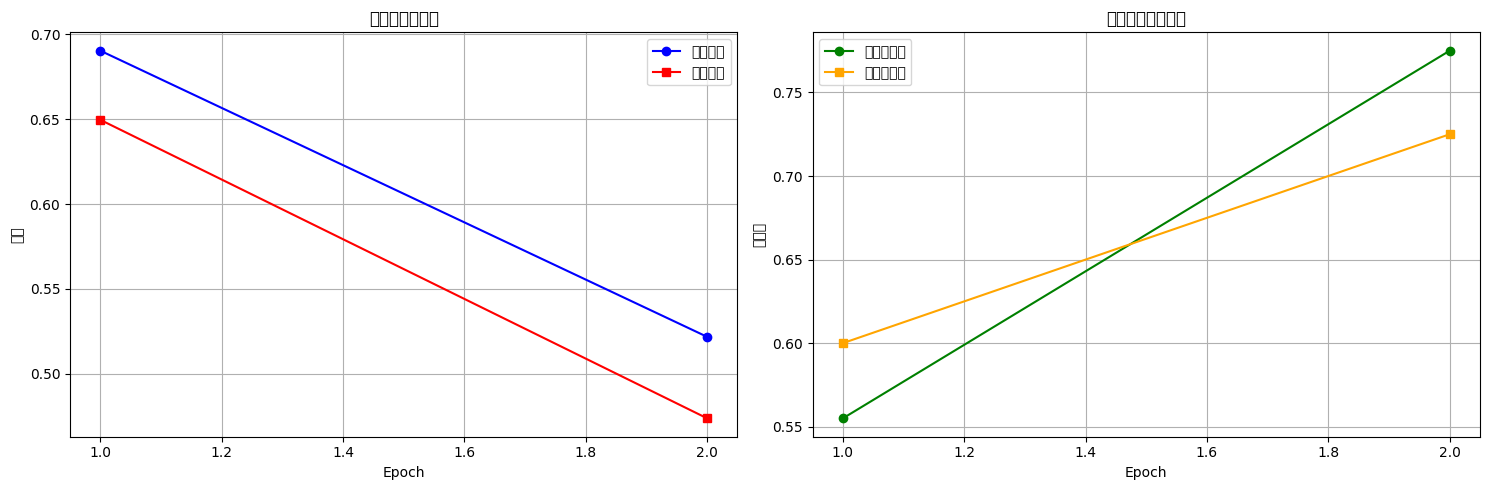


📋 步骤6: 详细评估模型
进行详细评估...


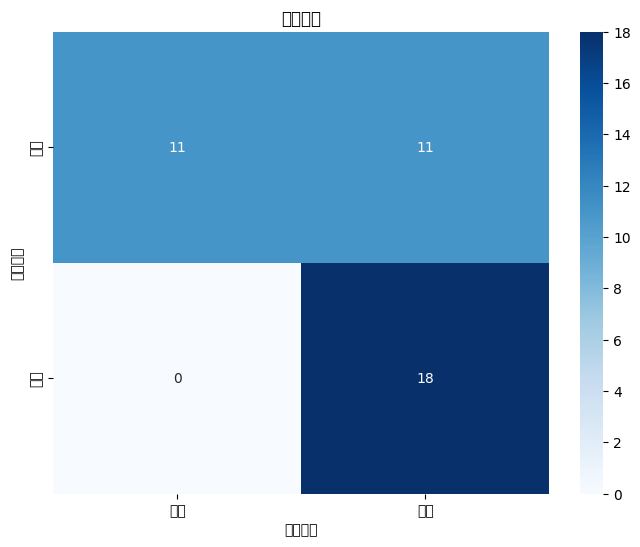


详细评估结果:
   类别      精确率  召回率      F1分数  支持数
0  负面  1.00000  0.5  0.666667   22
1  正面  0.62069  1.0  0.765957   18

总体准确率: 0.7250

🧪 步骤7: 测试模型推理
测试模型推理...

示例 1:
文本: I absolutely love this movie! It's fantastic and entertaining....
预测情感: 正面
置信度: 0.8764

示例 2:
文本: This film is terrible. I wasted my time watching it....
预测情感: 负面
置信度: 0.8146

示例 3:
文本: The movie was okay, nothing special but not bad either....
预测情感: 正面
置信度: 0.5821

示例 4:
文本: Outstanding performance by the actors. Highly recommended!...
预测情感: 正面
置信度: 0.7760

示例 5:
文本: Boring and predictable plot. Very disappointed....
预测情感: 负面
置信度: 0.7844

           微调完成！

📊 性能改进总结:
训练前准确率: 0.3500
训练后准确率: 0.7250
准确率提升: 0.3750 (37.50%)


In [18]:
import torch

import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from transformers import (
    DistilBertTokenizer, 
    DistilBertForSequenceClassification
)
from datasets import Dataset, load_dataset
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, confusion_matrix
from tqdm import tqdm
import warnings
warnings.filterwarnings('ignore')

import matplotlib
import platform

def setup_chinese_font():
    """设置中文字体"""
    try:
        # 根据操作系统选择合适的中文字体
        system = platform.system()
        if system == "Windows":
            plt.rcParams['font.sans-serif'] = ['SimHei', 'Microsoft YaHei', 'DejaVu Sans']
        elif system == "Darwin":  # macOS
            plt.rcParams['font.sans-serif'] = ['PingFang SC', 'Arial Unicode MS', 'DejaVu Sans']
        else:  # Linux
            plt.rcParams['font.sans-serif'] = ['WenQuanYi Micro Hei', 'DejaVu Sans', 'sans-serif']
        
        plt.rcParams['axes.unicode_minus'] = False  # 解决负号显示问题
        print("中文字体设置成功")
    except Exception as e:
        print(f"中文字体设置失败: {e}")
        # 使用英文标签作为备选
        plt.rcParams['font.sans-serif'] = ['DejaVu Sans']
        plt.rcParams['axes.unicode_minus'] = False

# 设置中文字体
setup_chinese_font()


class SimpleSentimentFineTuner:
    def __init__(self, model_name="distilbert-base-uncased", num_labels=2):
        """
        初始化微调器（简化版本，不使用Trainer）
        
        Args:
            model_name: 预训练模型名称
            num_labels: 分类标签数量
        """
        self.model_name = model_name
        self.num_labels = num_labels
        self.tokenizer = None
        self.model = None
        self.train_dataloader = None
        self.eval_dataloader = None
        self.raw_train_data = None
        self.raw_eval_data = None
        self.train_history = {'loss': [], 'accuracy': [], 'eval_loss': [], 'eval_accuracy': []}
        
        # 设置设备
        self.device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
        print(f"使用设备: {self.device}")
        
    def load_model_and_tokenizer(self):
        """加载预训练模型和分词器"""
        print("正在加载预训练模型和分词器...")
        
        try:
            # 加载分词器
            self.tokenizer = DistilBertTokenizer.from_pretrained(self.model_name)
            
            # 加载模型
            self.model = DistilBertForSequenceClassification.from_pretrained(
                self.model_name,
                num_labels=self.num_labels
            )
            
            # 移动到设备
            self.model.to(self.device)
            
            print("模型和分词器加载完成!")
            print(f"模型参数数量: {sum(p.numel() for p in self.model.parameters()):,}")
            
        except Exception as e:
            print(f"加载模型时出现错误: {e}")
            raise
    
    def prepare_data(self, max_samples=300):
        """准备训练数据"""
        print("正在准备数据...")
        
        try:
            # 加载IMDB数据集
            dataset = load_dataset("imdb")
            
            # 限制样本数量
            train_data = dataset["train"].shuffle(seed=42).select(range(max_samples))
            test_data = dataset["test"].shuffle(seed=42).select(range(max_samples//5))
            
            # 保存原始数据
            self.raw_train_data = train_data
            self.raw_eval_data = test_data
            
            # 创建数据加载器
            self.train_dataloader = self._create_dataloader(train_data, batch_size=4, shuffle=True)
            self.eval_dataloader = self._create_dataloader(test_data, batch_size=4, shuffle=False)
            
            print(f"训练集大小: {len(train_data)}")
            print(f"验证集大小: {len(test_data)}")
            
            # 可视化数据分布
            self.visualize_data_distribution()
            
        except Exception as e:
            print(f"准备数据时出现错误: {e}")
            raise
    
    def _create_dataloader(self, dataset, batch_size=4, shuffle=False):
        """创建数据加载器"""
        def collate_fn(batch):
            texts = [item['text'] for item in batch]
            labels = [item['label'] for item in batch]
            
            # 编码文本
            encoding = self.tokenizer(
                texts,
                truncation=True,
                padding=True,
                max_length=256,
                return_tensors='pt'
            )
            
            return {
                'input_ids': encoding['input_ids'],
                'attention_mask': encoding['attention_mask'],
                'labels': torch.tensor(labels, dtype=torch.long)
            }
        
        return DataLoader(dataset, batch_size=batch_size, shuffle=shuffle, collate_fn=collate_fn)
    
    def visualize_data_distribution(self):
        """可视化数据分布"""
        try:
            # 统计标签分布
            train_labels = [example["label"] for example in self.raw_train_data]
            eval_labels = [example["label"] for example in self.raw_eval_data]
            
            fig, axes = plt.subplots(1, 2, figsize=(12, 5))
            
            # 训练集标签分布
            axes[0].hist(train_labels, bins=2, alpha=0.7, color='skyblue', edgecolor='black')
            axes[0].set_title('训练集标签分布')
            axes[0].set_xlabel('标签 (0: 负面, 1: 正面)')
            axes[0].set_ylabel('样本数量')
            axes[0].set_xticks([0, 1])
            
            # 验证集标签分布
            axes[1].hist(eval_labels, bins=2, alpha=0.7, color='lightcoral', edgecolor='black')
            axes[1].set_title('验证集标签分布')
            axes[1].set_xlabel('标签 (0: 负面, 1: 正面)')
            axes[1].set_ylabel('样本数量')
            axes[1].set_xticks([0, 1])
            
            plt.tight_layout()
            plt.show()
            
            # 显示数据示例
            print("\n数据示例:")
            for i in range(3):
                example = self.raw_train_data[i]
                sentiment = "正面" if example["label"] == 1 else "负面"
                print(f"\n示例 {i+1} ({sentiment}):")
                print(f"文本: {example['text'][:150]}...")
                
        except Exception as e:
            print(f"可视化数据时出现错误: {e}")
    
    def evaluate(self, dataloader):
        """评估模型"""
        self.model.eval()
        total_loss = 0
        all_predictions = []
        all_labels = []
        
        with torch.no_grad():
            for batch in dataloader:
                input_ids = batch['input_ids'].to(self.device)
                attention_mask = batch['attention_mask'].to(self.device)
                labels = batch['labels'].to(self.device)
                
                outputs = self.model(input_ids=input_ids, attention_mask=attention_mask, labels=labels)
                loss = outputs.loss
                total_loss += loss.item()
                
                predictions = torch.argmax(outputs.logits, dim=-1)
                all_predictions.extend(predictions.cpu().numpy())
                all_labels.extend(labels.cpu().numpy())
        
        avg_loss = total_loss / len(dataloader)
        accuracy = accuracy_score(all_labels, all_predictions)
        
        return avg_loss, accuracy, all_predictions, all_labels
    
    def train(self, num_epochs=2, learning_rate=2e-5):
        """训练模型"""
        print("开始训练...")
        
        # 设置优化器
        optimizer = optim.AdamW(self.model.parameters(), lr=learning_rate)
        
        # 评估训练前性能
        print("评估训练前模型性能...")
        eval_loss_before, eval_acc_before, _, _ = self.evaluate(self.eval_dataloader)
        print(f"训练前 - 验证损失: {eval_loss_before:.4f}, 验证准确率: {eval_acc_before:.4f}")
        
        # 训练循环
        for epoch in range(num_epochs):
            print(f"\nEpoch {epoch + 1}/{num_epochs}")
            self.model.train()
            
            total_loss = 0
            all_predictions = []
            all_labels = []
            
            progress_bar = tqdm(self.train_dataloader, desc=f"训练 Epoch {epoch + 1}")
            
            for batch in progress_bar:
                # 移动数据到设备
                input_ids = batch['input_ids'].to(self.device)
                attention_mask = batch['attention_mask'].to(self.device)
                labels = batch['labels'].to(self.device)
                
                # 前向传播
                outputs = self.model(input_ids=input_ids, attention_mask=attention_mask, labels=labels)
                loss = outputs.loss
                
                # 反向传播
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()
                
                # 记录指标
                total_loss += loss.item()
                predictions = torch.argmax(outputs.logits, dim=-1)
                all_predictions.extend(predictions.cpu().numpy())
                all_labels.extend(labels.cpu().numpy())
                
                # 更新进度条
                progress_bar.set_postfix({'loss': loss.item()})
            
            # 计算训练指标
            avg_train_loss = total_loss / len(self.train_dataloader)
            train_accuracy = accuracy_score(all_labels, all_predictions)
            
            # 评估验证集
            eval_loss, eval_accuracy, _, _ = self.evaluate(self.eval_dataloader)
            
            # 记录历史
            self.train_history['loss'].append(avg_train_loss)
            self.train_history['accuracy'].append(train_accuracy)
            self.train_history['eval_loss'].append(eval_loss)
            self.train_history['eval_accuracy'].append(eval_accuracy)
            
            print(f"训练损失: {avg_train_loss:.4f}, 训练准确率: {train_accuracy:.4f}")
            print(f"验证损失: {eval_loss:.4f}, 验证准确率: {eval_accuracy:.4f}")
        
        # 评估训练后性能
        print("\n评估训练后模型性能...")
        eval_loss_after, eval_acc_after, _, _ = self.evaluate(self.eval_dataloader)
        print(f"训练后 - 验证损失: {eval_loss_after:.4f}, 验证准确率: {eval_acc_after:.4f}")
        
        return {
            'eval_accuracy_before': eval_acc_before,
            'eval_accuracy_after': eval_acc_after
        }
    
    def visualize_training_history(self):
        """可视化训练历史"""
        try:
            epochs = range(1, len(self.train_history['loss']) + 1)
            
            fig, axes = plt.subplots(1, 2, figsize=(15, 5))
            
            # 损失曲线
            axes[0].plot(epochs, self.train_history['loss'], label='训练损失', color='blue', marker='o')
            axes[0].plot(epochs, self.train_history['eval_loss'], label='验证损失', color='red', marker='s')
            axes[0].set_title('训练和验证损失')
            axes[0].set_xlabel('Epoch')
            axes[0].set_ylabel('损失')
            axes[0].legend()
            axes[0].grid(True)
            
            # 准确率曲线
            axes[1].plot(epochs, self.train_history['accuracy'], label='训练准确率', color='green', marker='o')
            axes[1].plot(epochs, self.train_history['eval_accuracy'], label='验证准确率', color='orange', marker='s')
            axes[1].set_title('训练和验证准确率')
            axes[1].set_xlabel('Epoch')
            axes[1].set_ylabel('准确率')
            axes[1].legend()
            axes[1].grid(True)
            
            plt.tight_layout()
            plt.show()
            
        except Exception as e:
            print(f"可视化训练历史时出现错误: {e}")
    
    def evaluate_detailed(self):
        """详细评估模型"""
        print("进行详细评估...")
        
        try:
            # 获取预测结果
            eval_loss, eval_accuracy, y_pred, y_true = self.evaluate(self.eval_dataloader)
            
            # 计算混淆矩阵
            cm = confusion_matrix(y_true, y_pred)
            
            # 可视化混淆矩阵
            plt.figure(figsize=(8, 6))
            sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                       xticklabels=['负面', '正面'], 
                       yticklabels=['负面', '正面'])
            plt.title('混淆矩阵')
            plt.xlabel('预测标签')
            plt.ylabel('真实标签')
            plt.show()
            
            # 计算详细指标
            precision, recall, f1, support = precision_recall_fscore_support(y_true, y_pred)
            
            # 创建结果表格
            results_df = pd.DataFrame({
                '类别': ['负面', '正面'],
                '精确率': precision,
                '召回率': recall,
                'F1分数': f1,
                '支持数': support
            })
            
            print("\n详细评估结果:")
            print(results_df)
            print(f"\n总体准确率: {eval_accuracy:.4f}")
            
            return results_df
            
        except Exception as e:
            print(f"评估过程中出现错误: {e}")
            return None
    
    def test_inference(self, test_texts):
        """测试推理"""
        print("测试模型推理...")
        
        try:
            self.model.eval()
            
            for i, text in enumerate(test_texts):
                try:
                    # 编码文本
                    inputs = self.tokenizer(text, return_tensors="pt", truncation=True, 
                                          padding=True, max_length=256)
                    inputs = {k: v.to(self.device) for k, v in inputs.items()}
                    
                    # 预测
                    with torch.no_grad():
                        outputs = self.model(**inputs)
                        predictions = torch.nn.functional.softmax(outputs.logits, dim=-1)
                        predicted_class = torch.argmax(predictions, dim=-1).item()
                        confidence = predictions[0][predicted_class].item()
                    
                    sentiment = "正面" if predicted_class == 1 else "负面"
                    print(f"\n示例 {i+1}:")
                    print(f"文本: {text[:100]}...")
                    print(f"预测情感: {sentiment}")
                    print(f"置信度: {confidence:.4f}")
                    
                except Exception as e:
                    print(f"处理示例 {i+1} 时出现错误: {e}")
                    
        except Exception as e:
            print(f"推理过程中出现错误: {e}")

def main():
    """主函数：完整的微调流程"""
    print("=" * 60)
    print("      大模型微调完整流程演示（简化版）")
    print("=" * 60)
    
    try:
        # 1. 初始化微调器
        print("\n🚀 步骤1: 初始化微调器")
        fine_tuner = SimpleSentimentFineTuner()
        
        # 2. 加载模型和分词器
        print("\n📥 步骤2: 加载预训练模型")
        fine_tuner.load_model_and_tokenizer()
        
        # 3. 准备数据
        print("\n📊 步骤3: 准备训练数据")
        fine_tuner.prepare_data(max_samples=200)  # 使用更小的数据集
        
        # 4. 开始微调
        print("\n🏋️ 步骤4: 开始微调训练")
        results = fine_tuner.train(num_epochs=2, learning_rate=2e-5)
        
        # 5. 可视化训练过程
        print("\n📈 步骤5: 可视化训练历史")
        fine_tuner.visualize_training_history()
        
        # 6. 详细评估
        print("\n📋 步骤6: 详细评估模型")
        results_df = fine_tuner.evaluate_detailed()
        
        # 7. 测试推理
        print("\n🧪 步骤7: 测试模型推理")
        test_texts = [
            "I absolutely love this movie! It's fantastic and entertaining.",
            "This film is terrible. I wasted my time watching it.",
            "The movie was okay, nothing special but not bad either.",
            "Outstanding performance by the actors. Highly recommended!",
            "Boring and predictable plot. Very disappointed."
        ]
        fine_tuner.test_inference(test_texts)
        
        print("\n" + "=" * 60)
        print("           微调完成！")
        print("=" * 60)
        
        # 总结改进效果
        improvement = results['eval_accuracy_after'] - results['eval_accuracy_before']
        print(f"\n📊 性能改进总结:")
        print(f"训练前准确率: {results['eval_accuracy_before']:.4f}")
        print(f"训练后准确率: {results['eval_accuracy_after']:.4f}")
        print(f"准确率提升: {improvement:.4f} ({improvement*100:.2f}%)")
        
    except Exception as e:
        print(f"程序执行过程中出现错误: {e}")
        import traceback
        traceback.print_exc()

if __name__ == "__main__":
    main()
